In [42]:
print ("Instalando as bibliotecas do projeto...")
!pip install pandas openpyxl folium matplotlib seaborn

Instalando as bibliotecas do projeto...
Defaulting to user installation because normal site-packages is not writeable


In [43]:
import pandas as pd

#Carregando o arquivo excel com os dados de furtos e roubos
df = pd.read_excel('VeiculosSubtraidos_2026.xlsx', sheet_name=2)

#Exibindo as colunas do dataframe
print("Colunas selecionadas no arquivo excel:")
print(df.columns.tolist())

df.head()

Colunas selecionadas no arquivo excel:
['ID_DELEGACIA', 'NOME_DEPARTAMENTO', 'NOME_SECCIONAL', 'NOME_DELEGACIA', 'NOME_MUNICIPIO', 'ANO_BO', 'NUM_BO', 'VERSAO', 'NOME_DEPARTAMENTO_CIRC', 'NOME_SECCIONAL_CIRC', 'NOME_DELEGACIA_CIRC', 'NOME_MUNICIPIO_CIRC', 'DATA_OCORRENCIA_BO', 'HORA_OCORRENCIA', 'DESCRICAO_APRESENTACAO', 'DATAHORA_REGISTRO_BO', 'DATA_COMUNICACAO_BO', 'DATAHORA_IMPRESSAO_BO', 'DESCR_PERIODO', 'AUTORIA_BO', 'FLAG_INTOLERANCIA', 'TIPO_INTOLERANCIA', 'FLAG_FLAGRANTE', 'FLAG_STATUS', 'DESC_LEI', 'FLAG_ATO_INFRACIONAL', 'RUBRICA', 'DESCR_CONDUTA', 'DESDOBRAMENTO', 'CIRCUNSTANCIA', 'DESCR_TIPOLOCAL', 'DESCR_SUBTIPOLOCAL', 'CIDADE', 'BAIRRO', 'CEP', 'DESC_NATUREZA_LOCAL', 'LOGRADOURO_VERSAO', 'LOGRADOURO', 'NUMERO_LOGRADOURO', 'LATITUDE', 'LONGITUDE', 'CONT_VEICULO', 'DESCR_OCORRENCIA_VEICULO', 'DESCR_TIPO_VEICULO', 'DESCR_MARCA_VEICULO', 'ANO_FABRICACAO', 'ANO_MODELO', 'PLACA_VEICULO', 'DESC_COR_VEICULO', 'MES_REGISTRO_BO', 'ANO_REGISTRO_BO', 'CMD', 'BTL', 'CIA', 'COD IBGE']


,ID_DELEGACIA,NOME_DEPARTAMENTO,NOME_SECCIONAL,NOME_DELEGACIA,NOME_MUNICIPIO,ANO_BO,NUM_BO,VERSAO,NOME_DEPARTAMENTO_CIRC,NOME_SECCIONAL_CIRC,...,ANO_FABRICACAO,ANO_MODELO,PLACA_VEICULO,DESC_COR_VEICULO,MES_REGISTRO_BO,ANO_REGISTRO_BO,CMD,BTL,CIA,COD IBGE
0,10108,DECAP,DEL.SEC.1º CENTRO,08º D.P. BRAS,S.PAULO,2026,AB9927,2,DECAP,DEL.SEC.1º CENTRO,...,2000.0,2001.0,DAD4B85,Prata,1,2026,CPA/M-1,7ºBPM/M,3ªCIA_4ªCIA,3550308
1,10108,DECAP,DEL.SEC.1º CENTRO,08º D.P. BRAS,S.PAULO,2026,AB9927,2,DECAP,DEL.SEC.1º CENTRO,...,2000.0,2001.0,DAD4B85,Prata,1,2026,CPA/M-1,7ºBPM/M,3ªCIA_4ªCIA,3550308
2,10108,DECAP,DEL.SEC.1º CENTRO,08º D.P. BRAS,S.PAULO,2026,AB9927,2,DECAP,DEL.SEC.1º CENTRO,...,2000.0,2001.0,DAD4B85,Prata,1,2026,CPA/M-1,7ºBPM/M,3ªCIA_4ªCIA,3550308
3,10108,DECAP,DEL.SEC.1º CENTRO,08º D.P. BRAS,S.PAULO,2026,AB9927,2,DECAP,DEL.SEC.1º CENTRO,...,2000.0,2001.0,DAD4B85,Prata,1,2026,CPA/M-1,7ºBPM/M,3ªCIA_4ªCIA,3550308
4,10101,DECAP,DEL.SEC.1º CENTRO,01º D.P. SE,S.PAULO,2026,AF6118,1,DECAP,DEL.SEC.1º CENTRO,...,2021.0,2022.0,RMR5J35,Vermelho,1,2026,CPA/M-1,7ºBPM/M,3ªCIA_4ªCIA,3550308


In [44]:
import pandas as pd

# Carregando o arquivo Excel
df = pd.read_excel('VeiculosSubtraidos_2026.xlsx', sheet_name=2)

# Selecionando colunas desejadas
df_selecionado = df[['RUBRICA', 'DESCR_TIPO_VEICULO', 'DATA_OCORRENCIA_BO',
                  'HORA_OCORRENCIA', 'LATITUDE', 'LONGITUDE']]

df_selecionado.head ()

,RUBRICA,DESCR_TIPO_VEICULO,DATA_OCORRENCIA_BO,HORA_OCORRENCIA,LATITUDE,LONGITUDE
0,Localização/Apreensão de veículo,Automovel,2026-01-03,09:50:00,-23.554290,-46.631983
1,Adulteração de sinal identificador de veículo ...,Automovel,2026-01-03,09:50:00,-23.554290,-46.631983
2,Localização/Apreensão e Entrega de veículo,Automovel,2026-01-03,09:50:00,-23.554290,-46.631983
3,Receptação (art. 180),Automovel,2026-01-03,09:50:00,-23.554290,-46.631983
4,Localização/Apreensão e Entrega de veículo,Automovel,2026-01-06,NaN,-23.545789,-46.634343


In [ ]:
#Estabelecendo filtro para apenas linhas que contém "Furto" na coluna "RUBRICA"
filtro_furtos = df_selecionado['RUBRICA'].str.contains('Furto', case=False, na=False)

#Estabelecendo filtro para apenas categoria de "Motociclos" na coluna "DESCR_TIPO_VEICULO"
filtro_motos = df_selecionado['DESCR_TIPO_VEICULO'].str.contains('^Moto', case=False, na=False)

#Aplicando os dois filtros juntos
df_filtrado = df_selecionado[filtro_furtos & filtro_motos].copy()

#Teste
#df_filtrado.head()

#Mostrando o tamanho da base de dados que iremos utilizar
print(f"Registro de furtos a motos, com coordenadas: {len(df_filtrado)}")

#Exibindo os dados filtrados
df_filtrado.head()


Registro de furtos a motos, com coordenadas: 12791


,RUBRICA,DESCR_TIPO_VEICULO,DATA_OCORRENCIA_BO,HORA_OCORRENCIA,LATITUDE,LONGITUDE
12,Furto (art. 155),Motociclo,2026-01-07,16:00:00,-23.540217,-46.630468
14,Furto (art. 155),Motociclo,2026-01-09,NaN,-23.537753,-46.632712
21,Furto (art. 155),Motociclo,2026-01-12,19:40:00,NaN,NaN
22,Furto (art. 155),Motociclo,2026-01-13,21:48:00,-23.557994,-46.632746
31,Furto (art. 155),Motociclo,2026-01-18,02:50:00,-23.545789,-46.634343


In [ ]:
import pandas as pd

# 1. Padronizando data e extraindo dias da semana
df_filtrado['DATA_OCORRENCIA_BO'] = pd.to_datetime(df_filtrado['DATA_OCORRENCIA_BO'], errors='coerce')
df_filtrado['DIA_SEMANA'] = df_filtrado['DATA_OCORRENCIA_BO'].dt.day_name()

traducao_dias = {
    'Monday': 'Segunda-feira', 'Tuesday': 'Terça-feira', 'Wednesday': 'Quarta-feira',
    'Thursday': 'Quinta-feira', 'Friday': 'Sexta-feira', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}
df_filtrado['DIA_SEMANA'] = df_filtrado['DIA_SEMANA'].map(traducao_dias)

# 2. Extraindo apenas a HORA (0 a 23) da coluna HORA_OCORRENCIA
# Converti para texto primeiro, peguei os 2 primeiros dígitos e transformei em número inteiro
df_filtrado['HORA'] = df_filtrado['HORA_OCORRENCIA'].astype(str).str[:2]
df_filtrado['HORA'] = pd.to_numeric(df_filtrado['HORA'], errors='coerce')

# Removendo linhas com dados ausentes
df_filtrado = df_filtrado.dropna(subset=['HORA', 'DIA_SEMANA'])
df_filtrado['HORA'] = df_filtrado['HORA'].astype(int)

# 3. Criando uma coluna descritiva para o "Período do Dia" (Janela de Horário)
def definir_periodo(hora):
    if 6 <= hora < 12: return 'Manhã'
    elif 12 <= hora < 18: return 'Tarde'
    elif 18 <= hora < 24: return 'Noite'
    else: return 'Madrugada'

df_filtrado['PERIODO'] = df_filtrado['HORA'].apply(definir_periodo)

print("Dados preparados com sucesso!")
print(df_filtrado[['DIA_SEMANA', 'HORA', 'PERIODO']].head())

Dados preparados com sucesso!
       DIA_SEMANA  HORA    PERIODO
12   Quarta-feira    16      Tarde
21  Segunda-feira    19      Noite
22    Terça-feira    21      Noite
31        Domingo     2  Madrugada
58    Terça-feira    20      Noite


In [50]:
# Verifica o número total de linhas e colunas restantes
print(f"Total de furtos de motocicletas encontrados: {df_filtrado.shape[0]}")

Total de furtos de motocicletas encontrados: 10292


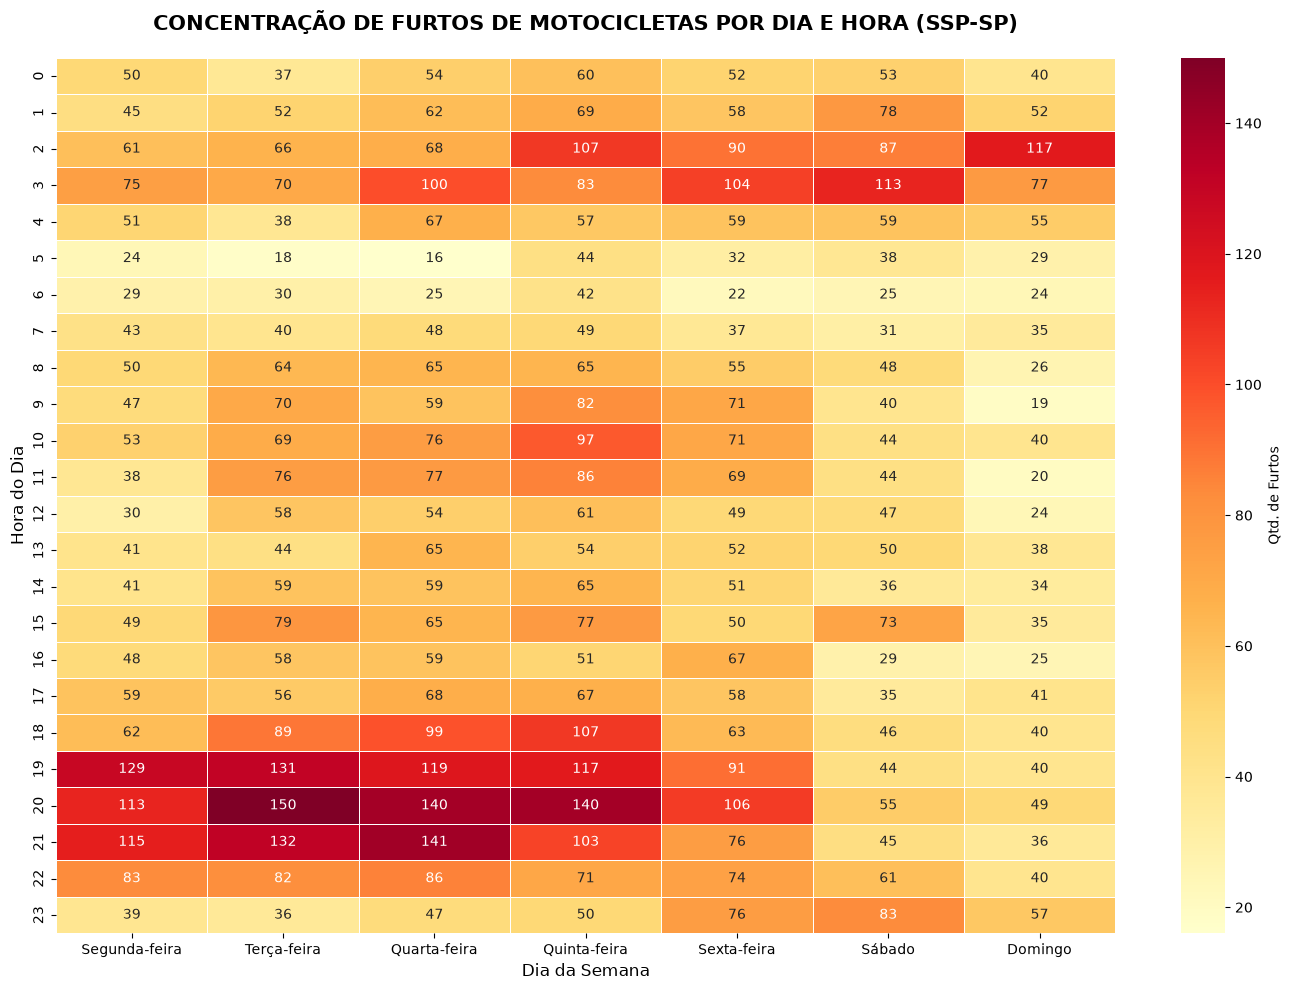

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Criando a tabela de cruzamento (Tabela Dinâmica)
matriz_horarios = pd.crosstab(df_filtrado['HORA'], df_filtrado['DIA_SEMANA'])

# 2. Organizando dias da semana pela ordem
dias_ordenados = ['Segunda-feira', 'Terça-feira', 'Quarta-feira', 'Quinta-feira', 'Sexta-feira', 'Sábado', 'Domingo']
matriz_horarios = matriz_horarios.reindex(columns=dias_ordenados).fillna(0)

# 3. Plota o gráfico de calor (Seaborn Heatmap)
plt.figure(figsize=(14, 10)) # Define o tamanho da imagem

# cmap='YlOrRd' usa cores do Amarelo ao Vermelho. annot=True coloca os números dentro das células
ax = sns.heatmap(matriz_horarios, cmap='YlOrRd', annot=True, fmt='g', linewidths=.5, cbar_kws={'label': 'Qtd. de Furtos'})

# Customizações para a apresentação do portfólio
plt.title('CONCENTRAÇÃO DE FURTOS DE MOTOCICLETAS POR DIA E HORA (SSP-SP)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Hora do Dia', fontsize=12)

# Rotaciona os nomes dos dias da semana para não ficarem apertados
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
#Criando mapa de calor de ocorrências

import folium
from folium.plugins import HeatMap
import pandas as pd

# 1. Centro de SP (Praça da Sé)
lat_centro = -23.5505
lng_centro = -46.6333

# Usando o mapa base claro (minimalista)
mapa_unico = folium.Map(location=[lat_centro, lng_centro], zoom_start=11, tiles='CartoDB positron')

# Configuração de degradê customizada (Amarelo -> Laranja -> Vermelho)
degrade_cores = {
    0.2: 'blue',      # Pontos muito isolados começam em azul suave
    0.4: 'yellow',    # Concentração baixa
    0.6: 'orange',    # Concentração média
    1.0: 'red'        # Concentração crítica (picos)
}

# 2. Dias da semana
dias_ordenados = ['Segunda-feira', 'Terça-feira', 'Quarta-feira', 'Quinta-feira', 'Sexta-feira', 'Sábado', 'Domingo']

# 3. Criar uma Camada de Calor para cada dia da semana com suavização
for dia in dias_ordenados:
    df_dia = df_filtrado[df_filtrado['DIA_SEMANA'] == dia]
    coordenadas = df_dia[['LATITUDE', 'LONGITUDE']].dropna()
    coordenadas = coordenadas[(coordenadas['LATITUDE'] != 0) & (coordenadas['LONGITUDE'] != 0)].values.tolist()
    
    # Parâmetros calibrados para não estourar a cor ao dar zoom
    heatmap_layer = HeatMap(
        coordenadas, 
        name=dia, 
        radius=14,              # Tamanho equilibrado do ponto
        blur=15,                # Desfoque suave para mesclar os pontos
        min_opacity=0.4,        # Opacidade moderada e elegante
        max_zoom=13,            # Mantém a proporção ao dar zoom nas ruas
        gradient=degrade_cores, # Aplica o nosso degradê personalizado
        overlay=True, 
        show=False
    )
    heatmap_layer.add_to(mapa_unico)

# 4. Adicionar a Camada Geral (Todos os Furtos) - Começa ativada
coordenadas_gerais = df_filtrado[['LATITUDE', 'LONGITUDE']].dropna()
coordenadas_gerais = coordenadas_gerais[(coordenadas_gerais['LATITUDE'] != 0) & (coordenadas_gerais['LONGITUDE'] != 0)].values.tolist()

HeatMap(
    coordenadas_gerais, 
    name='Visão Geral (Todos os Furtos)', 
    radius=13, 
    blur=14, 
    min_opacity=0.4, 
    max_zoom=13, 
    gradient=degrade_cores,
    show=True
).add_to(mapa_unico)

# 5. Controle de camadas
folium.LayerControl(position='topright', collapsed=False).add_to(mapa_unico)

# 6. Salvar
mapa_unico.save('mapa_furtos_interativo.html')

print("Mapa atualizado com fundo claro e degradê de calor calibrado!")

Mapa atualizado com fundo claro e degradê de calor calibrado!
